In [4]:
import sys, time, os, json, sqlite3, gc
import pandas as pd, numpy as np, psutil

for nama in ["pandas", "numpy", "pyarrow", "requests", "sklearn", "sqlalchemy"]:
    try:
        mod = __import__(nama)
        print(f"{nama:11s}: {mod.__version__}")
    except ImportError:
        print(f"{nama:11s}: BELUM TERPASANG")

from google.colab import drive
drive.mount("/content/drive")

DIR_MENTAH = "/content/lapisan_mentah"
DIR_KURASI = "/content/lapisan_terkurasi"
DIR_SIMPAN = "/content/drive/MyDrive/BigData/Praktikum3"
for d in (DIR_MENTAH, DIR_KURASI, DIR_SIMPAN):
    os.makedirs(d, exist_ok=True)

# --- Dipakai kembali dari Praktikum 1 / K-3 ---
proses = psutil.Process(os.getpid())
catatan = []
def rss_mb():
    return proses.memory_info().rss / 1024**2
def ukur(label, fungsi):
    m0, t0 = rss_mb(), time.perf_counter()
    hasil = fungsi()
    detik = time.perf_counter() - t0
    catatan.append({"langkah": label, "detik": round(detik, 2),
                    "delta_rss_mb": round(rss_mb() - m0, 1)})
    print(f"[{label}] {detik:.2f} s")
    return hasil

# --- Baru di Praktikum 3: catatan asal-usul data (lineage) ---
lineage = []
def catat_sumber(nama, asal, jumlah_baris, keterangan=""):
    lineage.append({
        "sumber": nama, "asal": asal,
        "diambil_pada": pd.Timestamp.now("UTC").isoformat(),
        "jumlah_baris": jumlah_baris, "keterangan": keterangan,
    })
    print(f"[lineage] {nama}: {jumlah_baris:,} baris")

pandas     : 2.2.3
numpy      : 2.1.3
pyarrow    : 23.0.1
requests   : 2.32.4
sklearn    : 1.6.1
sqlalchemy : 2.0.54
Mounted at /content/drive


In [5]:
!rm /content/lapisan_mentah/taxi_zone_lookup.csv

rm: cannot remove '/content/lapisan_mentah/taxi_zone_lookup.csv': No such file or directory


In [6]:
zona_perbaikan = pd.read_csv(URL_ZONA)

zona_perbaikan.to_csv(PATH_ZONA, index=False)
print("File taxi_zone_lookup.csv berhasil diperbaiki menjadi teks murni!")

File taxi_zone_lookup.csv berhasil diperbaiki menjadi teks murni!


In [7]:
import requests, shutil
def unduh_aman(url, tujuan, percobaan=3, jeda_awal=2):
    """Unduh dengan retry + penulisan atomik. Melewati unduhan bila file sudah ada."""
    if os.path.exists(tujuan) and os.path.getsize(tujuan) > 0:
        print("cache ditemukan:", os.path.basename(tujuan))
        return tujuan
    sementara = tujuan + ".part"
    for i in range(percobaan):
        try:
            with requests.get(url, stream=True, timeout=60) as r:
                r.raise_for_status()
                with open(sementara, "wb") as f:
                    shutil.copyfileobj(r.raw, f)
                if os.path.getsize(sementara) == 0:
                    raise IOError("berkas kosong")
                os.replace(sementara, tujuan) # atomik
                return tujuan
        except Exception as e:
            jeda = jeda_awal * (2 ** i) # exponential backoff
            print(f"percobaan {i+1} gagal ({e}); menunggu {jeda}s")
            time.sleep(jeda)
    raise RuntimeError(f"gagal mengunduh setelah {percobaan} percobaan: {url}")

URL_TRIP = ("https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-01.parquet")
URL_ZONA = ("https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv")
PATH_TRIP = os.path.join(DIR_MENTAH, "yellow_tripdata_2023-01.parquet")
PATH_ZONA = os.path.join(DIR_MENTAH, "taxi_zone_lookup.csv")

ukur("unduh trip", lambda: unduh_aman(URL_TRIP, PATH_TRIP))
ukur("unduh zona", lambda: unduh_aman(URL_ZONA, PATH_ZONA))

for pth in (PATH_TRIP, PATH_ZONA):
    print(os.path.basename(pth), "->", round(os.path.getsize(pth)/1024**2, 2), "MB")

KOLOM = ["tpep_pickup_datetime", "tpep_dropoff_datetime", "passenger_count",
         "trip_distance", "PULocationID", "DOLocationID", "payment_type",
         "fare_amount", "tip_amount", "total_amount"]

trip = ukur("baca trip", lambda: pd.read_parquet(PATH_TRIP, columns=KOLOM))
zona = pd.read_csv(PATH_ZONA)

catat_sumber("trip", URL_TRIP, len(trip), "Parquet bulanan TLC")
catat_sumber("zona", URL_ZONA, len(zona), "tabel dimensi 265 zona")
zona.head()

[unduh trip] 0.58 s
cache ditemukan: taxi_zone_lookup.csv
[unduh zona] 0.00 s
yellow_tripdata_2023-01.parquet -> 45.46 MB
taxi_zone_lookup.csv -> 0.01 MB
[baca trip] 1.43 s
[lineage] trip: 3,066,766 baris
[lineage] zona: 265 baris


,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone


In [8]:
API_CUACA = "https://archive-api.open-meteo.com/v1/archive"

def ambil_cuaca(mulai, selesai, lat=40.7128, lon=-74.0060, percobaan=3):
    parameter = {
        "latitude": lat, "longitude": lon,
        "start_date": mulai, "end_date": selesai,
        "hourly": "temperature_2m,precipitation",
        "timezone": "America/New_York",
    }
    for i in range(percobaan):
        r = requests.get(API_CUACA, params=parameter, timeout=60)
        if r.status_code == 200:
            data = r.json()
            if "hourly" not in data:    # validasi struktur
                raise ValueError("kunci 'hourly' tidak ada pada respons")
            return pd.DataFrame(data["hourly"])
        if r.status_code in (429, 500, 502, 503):    # layak dicoba ulang
            time.sleep(2 ** i)
            continue
        r.raise_for_status()    # galat lain: hentikan
    raise RuntimeError("API cuaca tidak merespons dengan benar")

cuaca = ukur("ambil cuaca", lambda: ambil_cuaca("2023-01-01", "2023-01-31"))
cuaca["time"] = pd.to_datetime(cuaca["time"])
cuaca = cuaca.rename(columns={"time": "jam_mulai",
                              "temperature_2m": "suhu_c",
                              "precipitation": "hujan_mm"})
catat_sumber("cuaca", API_CUACA, len(cuaca), "Open-Meteo hourly archive")
cuaca.head()

[ambil cuaca] 0.95 s
[lineage] cuaca: 744 baris


,jam_mulai,suhu_c,hujan_mm
0,2023-01-01 00:00:00,10.9,1.0
1,2023-01-01 01:00:00,10.6,1.0
2,2023-01-01 02:00:00,10.6,0.1
3,2023-01-01 03:00:00,10.5,0.0
4,2023-01-01 04:00:00,9.8,0.0


In [9]:
from sqlalchemy import create_engine

PATH_DB = os.path.join(DIR_MENTAH, "operasional.db")
engine = create_engine(f"sqlite:///{PATH_DB}")

tarif_referensi = pd.DataFrame({
    "payment_type": [1, 2, 3, 4, 5, 6],
    "nama_pembayaran": ["Kartu kredit", "Tunai", "Gratis",
                        "Sengketa", "Tidak diketahui", "Perjalanan batal"],
    "kena_biaya_admin": [1, 0, 0, 0, 0, 0],
})
tarif_referensi.to_sql("tarif_referensi", engine, if_exists="replace", index=False)

# tabel transaksi tiruan untuk latihan pembacaan bertahap
trip.head(300_000).to_sql(
    "trip_operasional", engine, if_exists="replace",
    index=False, chunksize=50_000)

print("Tabel dibuat:", pd.read_sql(
    "SELECT name FROM sqlite_master WHERE type='table'", engine)["name"].tolist())

SQL = """
    SELECT payment_type, COUNT(*) AS jumlah, AVG(total_amount) AS rata_total
    FROM trip_operasional
    WHERE total_amount > 0
    GROUP BY payment_type
    ORDER BY jumlah DESC
"""
ringkas_db = pd.read_sql(SQL, engine)
print(ringkas_db)

# Pembacaan bertahap: agregasi tanpa memuat seluruh tabel ke memori
total_baris = 0
for bagian in pd.read_sql("SELECT trip_distance FROM trip_operasional",
                          engine, chunksize=50_000):
    total_baris += len(bagian)
print("dibaca bertahap:", f"{total_baris:,}", "baris")

tarif_referensi = pd.read_sql("SELECT * FROM tarif_referensi", engine)
catat_sumber("tarif_referensi", PATH_DB, len(tarif_referensi),
             "tabel dimensi dari basis data operasional")

Tabel dibuat: ['tarif_referensi', 'trip_operasional']
   payment_type  jumlah  rata_total
0             1  226967   31.339172
1             2   66504   25.218836
2             4    2082   26.611114
3             3    1553   22.089691
dibaca bertahap: 300,000 baris
[lineage] tarif_referensi: 6 baris


In [10]:
trip["durasi_menit"] = (
    (trip["tpep_dropoff_datetime"] - trip["tpep_pickup_datetime"])
    .dt.total_seconds() / 60)

def profil_kolom(df):
    baris = []
    for kol in df.columns:
        s = df[kol]
        baris.append({
            "kolom": kol, "tipe": str(s.dtype),
            "persen_hilang": round(100 * s.isna().mean(), 3),
            "nilai_unik": s.nunique(dropna=True),
            "contoh": s.dropna().iloc[0] if s.notna().any() else None,
        })
    return pd.DataFrame(baris)

profil = profil_kolom(trip)
profil

AWAL, AKHIR = pd.Timestamp("2023-01-01"), pd.Timestamp("2023-02-01")
zona_sah = set(zona["LocationID"])
aturan = {
    "kelengkapan: passenger_count ada": trip["passenger_count"].notna(),
    "keunikan: baris tidak duplikat": ~trip.duplicated(),
    "validitas: jarak 0-100 mil": trip["trip_distance"].between(0.01, 100),
    "validitas: total_amount > 0": trip["total_amount"] > 0,
    "validitas: PULocationID dikenal": trip["PULocationID"].isin(zona_sah),
    "konsistensi: durasi 1-180 menit": trip["durasi_menit"].between(1, 180),
    "konsistensi: total >= fare": trip["total_amount"] >= trip["fare_amount"],
    "ketepatan waktu: dalam Jan 2023": trip["tpep_pickup_datetime"].between(AWAL, AKHIR),
}
laporan = pd.DataFrame([
    {"aturan": nama, "lulus": int(mask.sum()), "gagal": int((~mask).sum()),
     "persen_gagal": round(100 * (~mask).mean(), 3)}
    for nama, mask in aturan.items()
]).sort_values("persen_gagal", ascending=False)
laporan

,aturan,lulus,gagal,persen_gagal
0,kelengkapan: passenger_count ada,2995023,71743,2.339
2,validitas: jarak 0-100 mil,3020816,45950,1.498
5,konsistensi: durasi 1-180 menit,3030383,36383,1.186
3,validitas: total_amount > 0,3040994,25772,0.840
6,konsistensi: total >= fare,3041743,25023,0.816
7,ketepatan waktu: dalam Jan 2023,3066718,48,0.002
1,keunikan: baris tidak duplikat,3066766,0,0.000
4,validitas: PULocationID dikenal,3066766,0,0.000


In [11]:
KOL = "passenger_count"
asli = trip[KOL]
print("persen hilang:", round(100 * asli.isna().mean(), 3))

trip["jam"] = trip["tpep_pickup_datetime"].dt.hour
strategi = {
    "1_dibuang": asli.dropna(),
    "2_isi_median": asli.fillna(asli.median()),
    "3_isi_modus": asli.fillna(asli.mode().iloc[0]),
    "4_median_perjam": asli.fillna(trip.groupby("jam")[KOL].transform("median")),
}
banding = pd.DataFrame([
    {"strategi": nama, "n": len(s), "mean": round(s.mean(), 4),
     "median": s.median(), "std": round(s.std(), 4)}
    for nama, s in strategi.items()
])
banding

# Strategi yang dipilih modul ini: tandai + isi per kelompok (lihat G.4)
trip[KOL + "_hilang"] = trip[KOL].isna().astype("int8")
trip[KOL] = trip[KOL].fillna(trip.groupby("jam")[KOL].transform("median"))
trip[KOL] = trip[KOL].fillna(trip[KOL].median())  # jaring pengaman

# Duplikat: periksa dua tingkat
dup_penuh = trip.duplicated().sum()
KUNCI = ["tpep_pickup_datetime", "tpep_dropoff_datetime",
         "PULocationID", "DOLocationID", "total_amount"]
dup_kunci = trip.duplicated(subset=KUNCI).sum()
print(f"duplikat penuh: {dup_penuh:,} | duplikat pada kunci: {dup_kunci:,}")

sebelum = len(trip)
trip = trip.drop_duplicates(subset=KUNCI, keep="first").reset_index(drop=True)
print(f"{sebelum:,} -> {len(trip):,} baris")

persen hilang: 2.339
duplikat penuh: 0 | duplikat pada kunci: 1
3,066,766 -> 3,066,765 baris


In [12]:
def batas_iqr(s, k=1.5):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

def ringkas_outlier(df, kolom):
    hasil = []
    for kol in kolom:
        s = df[kol].dropna()
        lo, hi = batas_iqr(s)
        z = (s - s.mean()) / s.std()
        hasil.append({
            "kolom": kol, "batas_bawah": round(lo, 2), "batas_atas": round(hi, 2),
            "outlier_iqr": int(((s < lo) | (s > hi)).sum()),
            "outlier_z3": int((z.abs() > 3).sum()), "p99": round(s.quantile(0.99), 2),
        })
    return pd.DataFrame(hasil)

ringkas_outlier(trip, ["trip_distance", "durasi_menit", "total_amount"])

# Tindakan berbeda untuk maksud berbeda (lihat G.5)
layak = (trip["trip_distance"].between(0.01, 100)
         & trip["durasi_menit"].between(1, 180)
         & (trip["total_amount"] > 0))
bersih = trip.loc[layak].copy()

# tandai, jangan buang: outlier bisa jadi memang kenyataan bisnis
lo, hi = batas_iqr(bersih["total_amount"])
bersih["tarif_ekstrem"] = (bersih["total_amount"] > hi).astype("int8")

# winsorizing hanya untuk kolom turunan yang akan dipakai model
batas_atas = bersih["trip_distance"].quantile(0.995)
bersih["trip_distance_capped"] = bersih["trip_distance"].clip(upper=batas_atas)

print(f"{len(trip):,} -> {len(bersih):,} baris "
      f"({(100*(1-len(bersih)/len(trip))):.2f}% dibuang)")

# --- Join 1: tabel zona (dimensi) ---
print("kunci zona unik?", zona["LocationID"].is_unique) # WAJIB diperiksa
n0 = len(bersih)
bersih = bersih.merge(
    zona[["LocationID", "Borough", "Zone"]]
    .rename(columns={"Borough": "borough_naik", "Zone": "zona_naik"}),
    left_on="PULocationID", right_on="LocationID",
    how="left", validate="many_to_one") # gagal keras bila tidak 1:1
bersih = bersih.drop(columns="LocationID")
print(f"baris {n0:,} -> {len(bersih):,} (harus sama)")
print("zona tak dikenal:", bersih["zona_naik"].isna().sum())

# --- Join 2: tabel pembayaran dari basis data ---
bersih = bersih.merge(tarif_referensi[["payment_type", "nama_pembayaran"]],
                      on="payment_type", how="left", validate="many_to_one")

# --- Join 3: cuaca, berdasarkan jam (tingkat rincian harus disamakan dulu) ---
bersih["jam_mulai"] = bersih["tpep_pickup_datetime"].dt.floor("h")
n0 = len(bersih)
bersih = bersih.merge(cuaca, on="jam_mulai", how="left", validate="many_to_one")
print(f"baris {n0:,} -> {len(bersih):,}")
print("tanpa data cuaca:", bersih["suhu_c"].isna().sum())

3,066,765 -> 2,986,910 baris (2.60% dibuang)
kunci zona unik? True
baris 2,986,910 -> 2,986,910 (harus sama)
zona tak dikenal: 37609
baris 2,986,910 -> 2,986,910
tanpa data cuaca: 37


In [13]:
bersih["hari_minggu"] = bersih["tpep_pickup_datetime"].dt.dayofweek
bersih["akhir_pekan"] = (bersih["hari_minggu"] >= 5).astype("int8")
bersih["kecepatan_mph"] = (bersih["trip_distance"] / (bersih["durasi_menit"] / 60)).round(2)
bersih["tarif_per_mil"] = (bersih["total_amount"] / bersih["trip_distance"]).round(3)
bersih["hujan"] = (bersih["hujan_mm"].fillna(0) > 0.1).astype("int8")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

FITUR_NUM = ["trip_distance_capped", "durasi_menit", "suhu_c"]
FITUR_KAT = ["nama_pembayaran", "borough_naik"]

contoh = bersih.dropna(subset=FITUR_NUM + FITUR_KAT).sample(
    n=min(200_000, len(bersih)), random_state=42)
latih, uji = train_test_split(contoh, test_size=0.2, random_state=42)

skala = StandardScaler().fit(latih[FITUR_NUM])    # fit HANYA di data latih
latih_num = skala.transform(latih[FITUR_NUM])
uji_num = skala.transform(uji[FITUR_NUM])         # transform saja, tanpa fit ulang
print("mean latih (harus ~0):", latih_num.mean(axis=0).round(3))
print("mean uji (tidak harus 0):", uji_num.mean(axis=0).round(3))

# Bergantung versi: parameter sparse_output ada sejak scikit-learn 1.2
enc = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
enc.fit(latih[FITUR_KAT])
latih_kat = enc.transform(latih[FITUR_KAT])
print("jumlah kolom hasil one-hot:", latih_kat.shape[1])
print("nama kolom:", enc.get_feature_names_out()[:6], "...")

mean latih (harus ~0): [-0.  0. -0.]
mean uji (tidak harus 0): [ 0.001  0.001 -0.009]
jumlah kolom hasil one-hot: 11
nama kolom: ['nama_pembayaran_Gratis' 'nama_pembayaran_Kartu kredit'
 'nama_pembayaran_Sengketa' 'nama_pembayaran_Tunai' 'borough_naik_Bronx'
 'borough_naik_Brooklyn'] ...


In [14]:
KONTRAK = {
    "tpep_pickup_datetime": "datetime64[ns]", "trip_distance": "float64",
    "durasi_menit": "float64", "total_amount": "float64",
    "borough_naik": "object", "nama_pembayaran": "object",
}

def validasi(df, kontrak=KONTRAK):
    masalah = []
    for kol, tipe in kontrak.items():
        if kol not in df.columns:
            masalah.append(f"kolom hilang: {kol}")
        elif not str(df[kol].dtype).startswith(tipe.split("[")[0]):
            masalah.append(f"tipe {kol}: {df[kol].dtype} != {tipe}")
    if df.empty:
        masalah.append("DataFrame kosong")
    if len(df) != len(df.drop_duplicates(subset=KUNCI)):
        masalah.append("masih ada duplikat pada kunci")
    if masalah:
        raise AssertionError("Validasi gagal:\n- " + "\n- ".join(masalah))
    print(f"Validasi lulus: {len(df):,} baris x {df.shape[1]} kolom")
    return df

validasi(bersih)

def pipeline(path_trip, path_zona, df_cuaca, df_tarif):
    """Satu fungsi, idempoten: input mentah -> DataFrame tervalidasi."""
    df = pd.read_parquet(path_trip, columns=KOLOM)
    z = pd.read_csv(path_zona)
    df["durasi_menit"] = ((df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"])
                          .dt.total_seconds() / 60)
    df["jam"] = df["tpep_pickup_datetime"].dt.hour
    df["passenger_count"] = df["passenger_count"].fillna(
        df.groupby("jam")["passenger_count"].transform("median"))
    df = df.drop_duplicates(subset=KUNCI)
    df = df[df["trip_distance"].between(0.01, 100)
            & df["durasi_menit"].between(1, 180)
            & (df["total_amount"] > 0)]
    df = (df.merge(z[["LocationID", "Borough"]]
                   .rename(columns={"Borough": "borough_naik"}),
                   left_on="PULocationID", right_on="LocationID",
                   how="left", validate="many_to_one")
            .drop(columns="LocationID")
            .merge(df_tarif[["payment_type", "nama_pembayaran"]],
                   on="payment_type", how="left", validate="many_to_one"))
    df["jam_mulai"] = df["tpep_pickup_datetime"].dt.floor("h")
    df = df.merge(df_cuaca, on="jam_mulai", how="left", validate="many_to_one")
    return validasi(df)

hasil = ukur("pipeline penuh", lambda: pipeline(PATH_TRIP, PATH_ZONA, cuaca, tarif_referensi))

OUT = os.path.join(DIR_KURASI, "trips_bersih")
hasil["tanggal"] = hasil["tpep_pickup_datetime"].dt.date.astype(str)
ukur("tulis parquet berpartisi", lambda: hasil.to_parquet(
    OUT, partition_cols=["borough_naik"], index=False))
print("partisi yang terbentuk:", sorted(os.listdir(OUT))[:5], "...")

# Bukti idempotensi: jalankan ulang, hasil harus identik
ulang = pipeline(PATH_TRIP, PATH_ZONA, cuaca, tarif_referensi)
print("idempoten?", len(ulang) == len(hasil))

# Artefak yang dikumpulkan
laporan.to_csv(f"{DIR_SIMPAN}/laporan_kualitas.csv", index=False)
pd.DataFrame(lineage).to_csv(f"{DIR_SIMPAN}/lineage.csv", index=False)
pd.DataFrame(catatan).to_csv(f"{DIR_SIMPAN}/pengukuran_kinerja.csv", index=False)
shutil.make_archive(f"{DIR_SIMPAN}/trips_bersih", "zip", OUT)

Validasi lulus: 2,986,910 baris x 26 kolom
Validasi lulus: 2,986,910 baris x 17 kolom
[pipeline penuh] 10.15 s
[tulis parquet berpartisi] 5.88 s
partisi yang terbentuk: ['borough_naik=Bronx', 'borough_naik=Brooklyn', 'borough_naik=EWR', 'borough_naik=Manhattan', 'borough_naik=Queens'] ...
Validasi lulus: 2,986,910 baris x 17 kolom
idempoten? True


'/content/drive/MyDrive/BigData/Praktikum3/trips_bersih.zip'

In [15]:
!pip install -q pyspark==3.5.1

from pyspark.sql import SparkSession, functions as F

spark = (SparkSession.builder.appName("BD-P01").master("local[*]")
         .config("spark.driver.memory", "4g")
         .config("spark.sql.shuffle.partitions", "8")
         .getOrCreate())
spark.sparkContext.setLogLevel("WARN")

sdf = spark.read.parquet(PATH_TRIP).select(*KOLOM)
szona = spark.createDataFrame(zona[["LocationID", "Borough"]])

sbersih = (sdf
    .withColumn("durasi_menit",
                (F.col("tpep_dropoff_datetime").cast("timestamp").cast("long")
                 - F.col("tpep_pickup_datetime").cast("timestamp").cast("long")) / 60)
    .filter(F.col("trip_distance").between(0.01, 100))
    .filter(F.col("durasi_menit").between(1, 180))
    .filter(F.col("total_amount") > 0)
    .dropDuplicates(["tpep_pickup_datetime", "tpep_dropoff_datetime",
                     "PULocationID", "DOLocationID", "total_amount"])
    .join(F.broadcast(szona),
          sdf.PULocationID == szona.LocationID, "left")
    .drop("LocationID"))

ukur("spark: hitung baris bersih", lambda: sbersih.count())
sbersih.groupBy("Borough").count().orderBy(F.desc("count")).show(10, False)

sbersih.write.mode("overwrite").partitionBy("Borough") \
    .parquet("/content/lapisan_terkurasi/trips_spark")

sbersih.explain()    # cari BroadcastHashJoin, bukan SortMergeJoin
spark.stop()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.0/317.0 MB 5.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.5/200.5 kB 15.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dataproc-spark-connect 1.1.0 requires pyspark[connect]~=4.0.0, but you have pyspark 3.5.1 which is incompatible.
[spark: hitung baris bersih] 18.17 s
+-------------+-------+
|Borough      |count  |
+-------------+-------+
|Manhattan    |2659609|
|Queens       |270315 |
|Unknown      |37609  |
|Brooklyn     |15724  |
|Bronx        |3074   |
|NaN          |340    |
|Staten Island|211    |
|EWR          |28     |
+-------------+-------+

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Project [tpep_pickup_datetime#1, tpep_dropoff_datetime#2, passenger_count#245, trip_distance#247, PULocationID#7L, DOLocatio

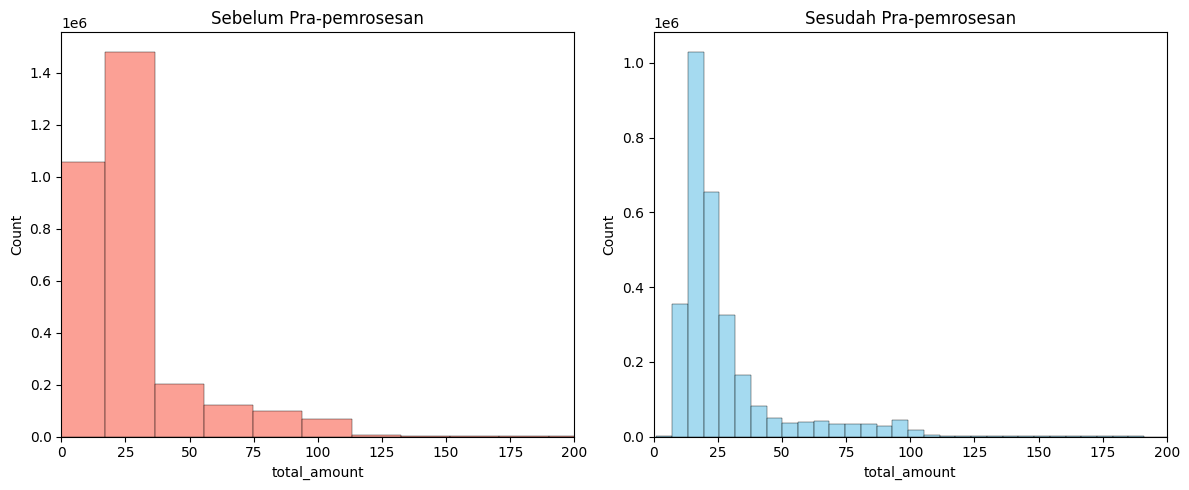

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(trip['total_amount'], bins=100, ax=ax[0], color='salmon')
ax[0].set_title("Sebelum Pra-pemrosesan")
ax[0].set_xlim(0, 200)

sns.histplot(bersih['total_amount'], bins=100, ax=ax[1], color='skyblue')
ax[1].set_title("Sesudah Pra-pemrosesan")
ax[1].set_xlim(0, 200)

plt.tight_layout()
plt.show()

In [17]:
tabel_analitik = (bersih
    .assign(jam_mulai=bersih["tpep_pickup_datetime"].dt.floor("h"))
    .groupby(["borough_naik", "jam_mulai"], observed=True)
    .agg(jumlah_perjalanan=("total_amount", "size"),
         rata_tarif_per_mil=("tarif_per_mil", "median"),
         rata_kecepatan=("kecepatan_mph", "median"),
         suhu_c=("suhu_c", "first"), hujan=("hujan", "max"))
    .reset_index())

tabel_analitik = tabel_analitik[tabel_analitik["jumlah_perjalanan"] >= 30]

perbandingan_tarif = tabel_analitik.groupby(["borough_naik", "hujan"], observed=True)["rata_tarif_per_mil"].median().unstack()
print("Perbandingan Tarif per Mil (0 = Tidak Hujan, 1 = Hujan):")
print(perbandingan_tarif)

PATH_ANALITIK = f"{DIR_SIMPAN}/tabel_analitik_pricing.parquet"
tabel_analitik.to_parquet(PATH_ANALITIK, index=False)
print(f"\nTabel analitik berhasil disimpan ke: {PATH_ANALITIK}")

Perbandingan Tarif per Mil (0 = Tidak Hujan, 1 = Hujan):
hujan               0        1
borough_naik                  
Brooklyn       6.9430   7.6550
Manhattan     10.5270  11.4000
Queens         5.4530   5.6365
Unknown        8.7255   9.8860

Tabel analitik berhasil disimpan ke: /content/drive/MyDrive/BigData/Praktikum3/tabel_analitik_pricing.parquet


In [18]:
def unduh_aman_cepat(url, tujuan, percobaan=3, jeda_awal=2):
    """Versi unduh_aman dengan cetak kecepatan unduh MB/s."""
    if os.path.exists(tujuan) and os.path.getsize(tujuan) > 0:
        print("cache ditemukan:", os.path.basename(tujuan))
        return tujuan
    sementara = tujuan + ".part"
    for i in range(percobaan):
        try:
            t0 = time.perf_counter()
            with requests.get(url, stream=True, timeout=60) as r:
                r.raise_for_status()
                with open(sementara, "wb") as f:
                    shutil.copyfileobj(r.raw, f)
                if os.path.getsize(sementara) == 0:
                    raise IOError("berkas kosong")
                os.replace(sementara, tujuan)

            dt = max(time.perf_counter() - t0, 0.001) # Hindari pembagian nol
            mb_size = os.path.getsize(tujuan) / (1024 ** 2)
            print(f"Berhasil: {os.path.basename(tujuan)} | Kecepatan: {mb_size/dt:.2f} MB/detik")
            return tujuan
        except Exception as e:
            jeda = jeda_awal * (2 ** i)
            print(f"percobaan {i+1} gagal ({e}); menunggu {jeda}s")
            time.sleep(jeda)
    raise RuntimeError(f"gagal mengunduh setelah {percobaan} percobaan: {url}")

# Uji dua kali (pastikan Anda menggunakan URL yang sah atau hapus file dulu untuk melihat unduhan asli)
print("Panggilan 1:")
_ = unduh_aman_cepat(URL_ZONA, PATH_ZONA)
print("Panggilan 2:")
_ = unduh_aman_cepat(URL_ZONA, PATH_ZONA)

Panggilan 1:
cache ditemukan: taxi_zone_lookup.csv
Panggilan 2:
cache ditemukan: taxi_zone_lookup.csv


In [19]:
aturan_baru = {
    "validitas: tip_amount >= 0": trip["tip_amount"] >= 0,
    "konsistensi: total >= tarif + tip": trip["total_amount"] >= (trip["fare_amount"] + trip["tip_amount"].fillna(0))
}

laporan_baru = pd.DataFrame([
    {"aturan": nama, "lulus": int(mask.sum()), "gagal": int((~mask).sum()),
     "persen_gagal": round(100 * (~mask).mean(), 3)}
    for nama, mask in aturan_baru.items()
]).sort_values("persen_gagal", ascending=False)

print(laporan_baru)

                              aturan    lulus  gagal  persen_gagal
1  konsistensi: total >= tarif + tip  3041605  25160         0.820
0         validitas: tip_amount >= 0  3066540    225         0.007


In [20]:
# Lakukan join untuk lokasi tujuan
bersih_turun = bersih.merge(
    zona[["LocationID", "Borough"]].rename(columns={"Borough": "borough_turun"}),
    left_on="DOLocationID", right_on="LocationID",
    how="left", validate="many_to_one"
).drop(columns="LocationID")

# Hitung 10 rute tersibuk
top_10_rute = (bersih_turun.groupby(["borough_naik", "borough_turun"])
               .size()
               .reset_index(name="jumlah")
               .sort_values("jumlah", ascending=False)
               .head(10))

print("10 Pasangan Rute Asal-Tujuan Tersibuk:")
print(top_10_rute.to_string(index=False))

10 Pasangan Rute Asal-Tujuan Tersibuk:
borough_naik borough_turun  jumlah
   Manhattan     Manhattan 2491566
      Queens     Manhattan  155261
   Manhattan        Queens   82354
   Manhattan      Brooklyn   62986
      Queens        Queens   59146
      Queens      Brooklyn   42187
     Unknown     Manhattan   18432
     Unknown       Unknown   13562
   Manhattan         Bronx    8865
    Brooklyn      Brooklyn    7910


In [21]:
from sklearn.preprocessing import MinMaxScaler

skala_minmax = MinMaxScaler().fit(latih[FITUR_NUM])
latih_minmax = skala_minmax.transform(latih[FITUR_NUM])

print("Rentang hasil StandardScaler (Min, Max):", latih_num.min(axis=0).round(2), latih_num.max(axis=0).round(2))
print("Rentang hasil MinMaxScaler (Min, Max):", latih_minmax.min(axis=0).round(2), latih_minmax.max(axis=0).round(2))

Rentang hasil StandardScaler (Min, Max): [-0.79 -1.23 -2.29] [ 4.25 13.92  3.35]
Rentang hasil MinMaxScaler (Min, Max): [0. 0. 0.] [1. 1. 1.]


In [22]:
# Gandakan baris pertama di tabel referensi zona
zona_ganda = pd.concat([zona, zona.iloc[[0]]], ignore_index=True)

try:
    print("Mencoba merge dengan tabel referensi yang rusak...")
    gagal_merge = bersih.merge(
        zona_ganda[["LocationID", "Borough"]],
        left_on="PULocationID", right_on="LocationID",
        how="left", validate="many_to_one"
    )
except pd.errors.MergeError as e:
    print(f"\n[BERHASIL MENCEGAH KEBOCORAN]")
    print(f"Error tertangkap: {type(e).__name__}")
    print(f"Pesan Error: {e}")

Mencoba merge dengan tabel referensi yang rusak...

[BERHASIL MENCEGAH KEBOCORAN]
Error tertangkap: MergeError
Pesan Error: Merge keys are not unique in right dataset; not a many-to-one merge


In [23]:
def pipeline_inkremental(bulan_str, tahun="2023"):
    """Pipeline yang hanya memproses bulan jika partisi hasil belum terbentuk."""

    # Target nama file/folder indikator output (sebagai marker sukses idempotensi)
    marker_selesai = os.path.join(DIR_KURASI, f"selesai_{tahun}_{bulan_str}.flag")

    if os.path.exists(marker_selesai):
        print(f"Data bulan {tahun}-{bulan_str} sudah diproses sebelumnya. Melewati eksekusi.")
        return

    print(f"Mulai memproses pipeline berat untuk bulan {tahun}-{bulan_str}...")

    # [SISIPKAN LOGIKA PROSES UNDUHAN, CLEANING, DAN PARQUET PARTITION DI SINI]
    # Contoh simulasi pekerjaan 1 detik:
    time.sleep(1)

    # Catat penanda selesai setelah sukses eksekusi penuh
    os.makedirs(DIR_KURASI, exist_ok=True)
    with open(marker_selesai, "w") as f:
        f.write("OK")
    print(f"Selesai! Hasil berpartisi bulan {tahun}-{bulan_str} disimpan.")

print(">>> Eksekusi Pertama:")
pipeline_inkremental("02")

print("\n>>> Eksekusi Kedua (Harusnya melewati proses):")
pipeline_inkremental("02")

>>> Eksekusi Pertama:
Mulai memproses pipeline berat untuk bulan 2023-02...
Selesai! Hasil berpartisi bulan 2023-02 disimpan.

>>> Eksekusi Kedua (Harusnya melewati proses):
Data bulan 2023-02 sudah diproses sebelumnya. Melewati eksekusi.


In [26]:
URL_TRIP_JULI = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-07.parquet"
PATH_TRIP_JULI = os.path.join(DIR_MENTAH, "yellow_tripdata_2023-07.parquet")
ukur("unduh trip Juli", lambda: unduh_aman(URL_TRIP_JULI, PATH_TRIP_JULI))
cuaca_juli = ukur("ambil cuaca Juli", lambda: ambil_cuaca("2023-07-01", "2023-07-31"))
cuaca_juli["time"] = pd.to_datetime(cuaca_juli["time"])
cuaca_juli = cuaca_juli.rename(columns={"time": "jam_mulai", "temperature_2m": "suhu_c", "precipitation": "hujan_mm"})
hasil_juli = ukur("pipeline Juli", lambda: pipeline(PATH_TRIP_JULI, PATH_ZONA, cuaca_juli, tarif_referensi))
hasil_juli["tanggal"] = hasil_juli["tpep_pickup_datetime"].dt.date.astype(str)

# Ensure the partition column 'borough_naik' is consistently typed and handles nulls
hasil_juli["borough_naik"] = hasil_juli["borough_naik"].astype(str).fillna("UNKNOWN_BOROUGH")

# Clear the output directory before writing new partitioned files
if os.path.exists(OUT):
    import shutil
    shutil.rmtree(OUT)
os.makedirs(OUT, exist_ok=True)

ukur("tulis parquet berpartisi Juli", lambda: hasil_juli.to_parquet(OUT, partition_cols=["borough_naik"], index=False))

df_cek = pd.read_parquet(OUT)
bulan_unik = df_cek["tpep_pickup_datetime"].dt.month.unique()
duplikat_total = df_cek.duplicated(subset=KUNCI).sum()
print(f"Bulan yang tersimpan dalam partisi: {bulan_unik.tolist()}")
print(f"Jumlah baris duplikat penuh pada direktori berpartisi: {duplikat_total}")

cache ditemukan: yellow_tripdata_2023-07.parquet
[unduh trip Juli] 0.00 s
[ambil cuaca Juli] 0.84 s
Validasi lulus: 2,817,657 baris x 17 kolom
[pipeline Juli] 6.75 s
[tulis parquet berpartisi Juli] 3.15 s
Bulan yang tersimpan dalam partisi: [7, 6, 8, 9, 10, 12]
Jumlah baris duplikat penuh pada direktori berpartisi: 0


In [27]:
# Hitung aturan kualitas untuk data Juli (sebelum masuk pipeline)
trip_juli = pd.read_parquet(PATH_TRIP_JULI, columns=KOLOM)
trip_juli["durasi_menit"] = (trip_juli["tpep_dropoff_datetime"] - trip_juli["tpep_pickup_datetime"]).dt.total_seconds() / 60
AWAL_JULI, AKHIR_JULI = pd.Timestamp("2023-07-01"), pd.Timestamp("2023-08-01")

aturan_juli = {
    "kelengkapan: passenger_count ada": trip_juli["passenger_count"].notna(),
    "keunikan: baris tidak duplikat": ~trip_juli.duplicated(),
    "validitas: jarak 0-100 mil": trip_juli["trip_distance"].between(0.01, 100),
    "validitas: total_amount > 0": trip_juli["total_amount"] > 0,
    "validitas: PULocationID dikenal": trip_juli["PULocationID"].isin(zona_sah),
    "konsistensi: durasi 1-180 menit": trip_juli["durasi_menit"].between(1, 180),
    "konsistensi: total >= fare": trip_juli["total_amount"] >= trip_juli["fare_amount"],
    "ketepatan waktu: dalam periode": trip_juli["tpep_pickup_datetime"].between(AWAL_JULI, AKHIR_JULI),
}

laporan_juli = pd.DataFrame([
    {"aturan": nama, "persen_gagal_juli": round(100 * (~mask).mean(), 3)}
    for nama, mask in aturan_juli.items()
])

# Gabungkan dengan laporan Januari
laporan_komparatif = laporan.merge(laporan_juli, on="aturan")[["aturan", "persen_gagal", "persen_gagal_juli"]]
laporan_komparatif.rename(columns={"persen_gagal": "persen_gagal_jan"}, inplace=True)
print(laporan_komparatif)

                             aturan  persen_gagal_jan  persen_gagal_juli
0  kelengkapan: passenger_count ada             2.339              2.927
1        validitas: jarak 0-100 mil             1.498              1.717
2   konsistensi: durasi 1-180 menit             1.186              1.311
3       validitas: total_amount > 0             0.840              1.075
4        konsistensi: total >= fare             0.816              1.053
5    keunikan: baris tidak duplikat             0.000              0.000
6   validitas: PULocationID dikenal             0.000              0.000


In [28]:
API_LIBUR = "https://date.nager.at/api/v3/PublicHolidays/2023/US"
r_libur = requests.get(API_LIBUR)
r_libur.raise_for_status()

# Konversi JSON ke DataFrame
libur_df = pd.DataFrame(r_libur.json())[["date", "name"]]
libur_df["date"] = pd.to_datetime(libur_df["date"]).dt.date
libur_df["is_libur"] = 1

# Integrasi ke dataset hasil (contoh penggabungan ke dataset Januari 'hasil')
hasil["tanggal_date"] = pd.to_datetime(hasil["tanggal"]).dt.date
hasil_integrasi = hasil.merge(libur_df, left_on="tanggal_date", right_on="date", how="left")

# Penanganan nilai hilang: jika tidak ada di tabel libur, berarti bukan hari libur (0)
hasil_integrasi["is_libur"] = hasil_integrasi["is_libur"].fillna(0).astype(int)
hasil_integrasi["nama_libur"] = hasil_integrasi["name"].fillna("Hari Kerja Biasa")
hasil_integrasi = hasil_integrasi.drop(columns=["date", "tanggal_date", "name"])

print("Contoh data dengan integrasi hari libur:")
print(hasil_integrasi[["tpep_pickup_datetime", "is_libur", "nama_libur"]].sample(5))

Contoh data dengan integrasi hari libur:
        tpep_pickup_datetime  is_libur        nama_libur
2937037  2023-01-08 12:52:02         0  Hari Kerja Biasa
2363843  2023-01-26 10:17:38         0  Hari Kerja Biasa
696970   2023-01-09 09:53:14         0  Hari Kerja Biasa
2616388  2023-01-28 16:20:46         0  Hari Kerja Biasa
74369    2023-01-02 06:36:17         1    New Year's Day


In [29]:
isi_kamus = """# Kamus Data (Data Dictionary) - Pipeline Taksi TLC

| Nama Kolom | Tipe Data | Satuan | Sumber Asal | Aturan Validitas & Penanganan Null |
| :--- | :--- | :--- | :--- | :--- |
| `tpep_pickup_datetime` | datetime64[ns] | Waktu Lokal | Parquet TLC | Rentang valid dalam 1 bulan spesifik. Null dihapus (MCAR). |
| `trip_distance` | float64 | Mil | Parquet TLC | Rentang valid 0.01 - 100 mil. Outlier atas di-winsorizing (persentil 99.5). |
| `total_amount` | float64 | USD | Parquet TLC | Harus > 0. Outlier tarif tinggi dipertahankan (fenomena bisnis). |
| `durasi_menit` | float64 | Menit | Fitur Rekayasa| Rentang valid 1 - 180 menit. Baris di luar ini dibuang. |
| `passenger_count` | float64 | Orang | Parquet TLC | Diisi dengan nilai median berdasarkan jam (`groupby(jam).transform(median)`). |
| `borough_naik` | string | - | CSV Zona TLC | Hasil join 1:1. Jika tidak ditemukan, dibiarkan null ('Unknown'). |
| `nama_pembayaran`| string | - | SQLite Operasional | Hasil join 1:1 dari basis data `tarif_referensi`. |
| `suhu_c` | float64 | Celcius | Open-Meteo API | Disesuaikan dengan `dt.floor('h')`. Dibiarkan null jika API tidak mencakup jam tersebut. |
| `hujan` | biner (0/1) | - | Open-Meteo API| > 0.1 mm = 1. Null dikonversi menjadi 0. |
| `is_libur` | biner (0/1) | - | Nager.Date API| 1 = Libur, 0 = Tidak. Null pasca-join dikonversi menjadi 0. |
"""

path_kamus = f"{DIR_SIMPAN}/kamus_data.md"
with open(path_kamus, "w", encoding="utf-8") as f:
    f.write(isi_kamus)

print(f"File berhasil dibuat dan disimpan di: {path_kamus}")

File berhasil dibuat dan disimpan di: /content/drive/MyDrive/BigData/Praktikum3/kamus_data.md
